In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
households_df = pd.read_csv("data/household.csv")
households_df.describe()

,HOUSEHOLD_ID,IN_TPB,IN_BMC,HOME_STATE_FIPS,AREA_TYPE,HOME_STATE_COUNTY_FIPS,HOME_TRACT_FIPS,HOME_TPB_TAZ,HOME_BMC_TAZ,HOME_TYPE,...,MPO_HH_INCOME_BROAD,TDATE_DOW,HHTRIPS,PACKAGE_DELIVERED,FOOD_DELIVERED,SERVICE_DELIVERED,WTHHFIN,HOME_OWNERSHIP_IMP,HH_INCOME_DETAILED_IMP,NUMDISABILITIES_IMP
count,1.801500e+04,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,...,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000,18015.000000
mean,1.733655e+08,0.998057,0.560200,33.145157,2.624535,33215.130835,530490.261449,1842.047127,948.396947,1.809270,...,-0.005051,2.996336,7.054399,0.242687,0.028698,0.055121,149.339694,-0.935332,-0.728893,-0.920899
std,1.135731e+07,0.044036,0.496377,14.974619,4.459310,15037.845994,305048.127741,1093.660828,1004.654531,0.900965,...,4.091130,1.418207,5.486647,0.428719,0.166962,0.228222,116.604905,2.777106,2.754609,2.770127
min,1.400003e+08,0.000000,0.000000,11.000000,0.000000,11001.000000,100.000000,-9.000000,-9.000000,-9.000000,...,-9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,9.000000,-9.000000,-9.000000,-9.000000
25%,1.700568e+08,1.000000,0.000000,24.000000,0.000000,24017.000000,201600.000000,799.000000,-9.000000,1.000000,...,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,78.000000,0.000000,0.000000,0.000000
50%,1.800420e+08,1.000000,1.000000,24.000000,1.000000,24033.000000,611208.000000,1757.000000,499.000000,2.000000,...,2.000000,3.000000,6.000000,0.000000,0.000000,0.000000,125.000000,0.000000,0.000000,0.000000
75%,1.801498e+08,1.000000,1.000000,51.000000,1.000000,51059.000000,752203.000000,2984.000000,1902.000000,3.000000,...,2.000000,4.000000,10.000000,0.000000,0.000000,0.000000,181.867322,0.000000,0.000000,0.000000
max,1.802569e+08,1.000000,1.000000,54.000000,13.000000,54037.000000,972800.000000,3675.000000,2934.000000,5.000000,...,2.000000,5.000000,53.000000,1.000000,1.000000,1.000000,2554.000000,1.000000,1.000000,1.000000


In [14]:
print("unique state codes: ", households_df["HOME_STATE_FIPS"].unique())
print("unique county codes: ", households_df["HOME_STATE_COUNTY_FIPS"].unique())

unique state codes:  [24 11 51 54]
unique county codes:  [24003 24013 24027 11001 24033 24031 51683 54037 51153 51059 51177 51179
 51013 51061 24017 24021 24009 51107 51610 51510 24037 51630 51600 51099
 51043 51685]


### State FIPS lookup (4 states in dataset)

| FIPS | State |
|---|---|
| 11 | District of Columbia (DC) |
| 24 | Maryland (MD) |
| 51 | Virginia (VA) |
| 54 | West Virginia (WV) |

### County FIPS lookup (26 counties in dataset)

| FIPS | County | State |
|---|---|---|
| 11001 | District of Columbia | DC |
| 24003 | Anne Arundel | MD |
| 24009 | Calvert | MD |
| 24013 | Carroll | MD |
| 24017 | Charles | MD |
| 24021 | Frederick | MD |
| 24027 | Howard | MD |
| 24031 | Montgomery | MD |
| 24033 | Prince George's | MD |
| 24037 | St. Mary's | MD |
| 51013 | Arlington | VA |
| 51043 | Clarke | VA |
| 51059 | Fairfax (county) | VA |
| 51061 | Fauquier | VA |
| 51099 | King George | VA |
| 51107 | Loudoun | VA |
| 51153 | Prince William | VA |
| 51177 | Spotsylvania | VA |
| 51179 | Stafford | VA |
| 51510 | Alexandria (city) | VA |
| 51600 | Fairfax (city) | VA |
| 51610 | Falls Church (city) | VA |
| 51630 | Fredericksburg (city) | VA |
| 51683 | Manassas (city) | VA |
| 51685 | Manassas Park (city) | VA |
| 54037 | Jefferson | WV |

*Note: VA `515xx`/`516xx` = independent cities (county-equivalents, separate FIPS from surrounding county). Fairfax city `51600` ≠ Fairfax county `51059`.*

Source (US Census): https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt

#### __We need to decide which county the this study should be based on. For now, this notebook will use Fairfax County. Can be changed later.__

In [17]:
COUNTY_CODE = 51059 # Fairfax county
fx_households = households_df[households_df["HOME_STATE_COUNTY_FIPS"] == COUNTY_CODE]
fx_households.describe()

,HOUSEHOLD_ID,IN_TPB,IN_BMC,HOME_STATE_FIPS,AREA_TYPE,HOME_STATE_COUNTY_FIPS,HOME_TRACT_FIPS,HOME_TPB_TAZ,HOME_BMC_TAZ,HOME_TYPE,...,MPO_HH_INCOME_BROAD,TDATE_DOW,HHTRIPS,PACKAGE_DELIVERED,FOOD_DELIVERED,SERVICE_DELIVERED,WTHHFIN,HOME_OWNERSHIP_IMP,HH_INCOME_DETAILED_IMP,NUMDISABILITIES_IMP
count,2.123000e+03,2123.0,2123.0,2123.0,2123.000000,2123.0,2123.000000,2123.000000,2123.0,2123.000000,...,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000
mean,1.765091e+08,1.0,0.0,51.0,0.401319,51059.0,458291.259538,1887.641074,-9.0,1.785210,...,1.897786,3.011776,7.083373,0.265191,0.026849,0.067829,190.881771,0.018841,0.189826,0.021196
std,4.835817e+06,0.0,0.0,0.0,0.490281,0.0,25948.788925,163.262968,0.0,0.857427,...,0.303001,1.420648,5.492701,0.441539,0.161679,0.251511,131.893249,0.135996,0.392256,0.144073
min,1.700005e+08,1.0,0.0,51.0,0.000000,51059.0,415100.000000,1611.000000,-9.0,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,61.000000,0.000000,0.000000,0.000000
25%,1.700771e+08,1.0,0.0,51.0,0.000000,51059.0,431802.000000,1739.000000,-9.0,1.000000,...,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,105.000000,0.000000,0.000000,0.000000
50%,1.800580e+08,1.0,0.0,51.0,0.000000,51059.0,461100.000000,1903.000000,-9.0,2.000000,...,2.000000,3.000000,6.000000,0.000000,0.000000,0.000000,161.000000,0.000000,0.000000,0.000000
75%,1.801590e+08,1.0,0.0,51.0,1.000000,51059.0,481900.000000,2038.000000,-9.0,3.000000,...,2.000000,4.000000,10.000000,1.000000,0.000000,0.000000,241.500000,0.000000,0.000000,0.000000
max,1.802569e+08,1.0,0.0,51.0,1.000000,51059.0,492500.000000,2158.000000,-9.0,4.000000,...,2.000000,5.000000,48.000000,1.000000,1.000000,1.000000,1793.000000,1.000000,1.000000,1.000000


### Households in fx county data exploration

In [ ]:
sns.set_theme(style="darkgrid", context="notebook")
plt.style.use("dark_background")

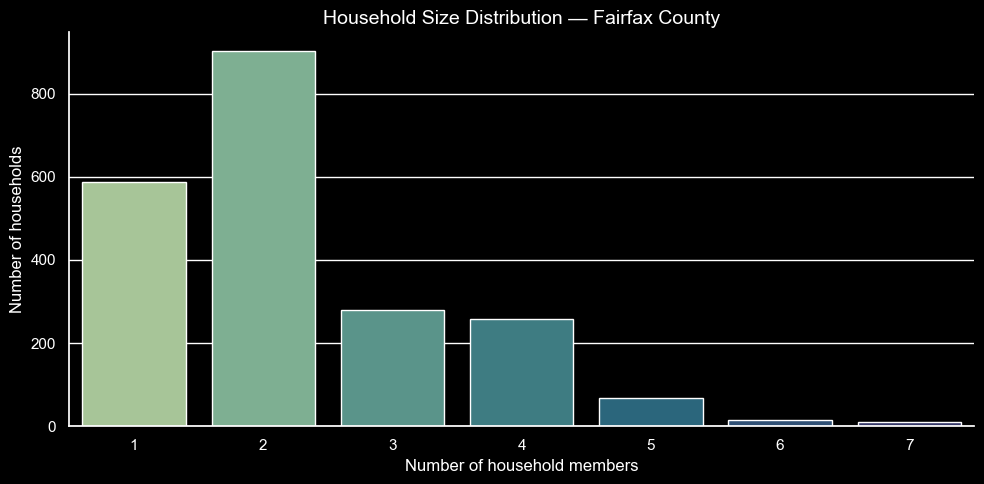

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))
size_order = sorted(fx_households["HHSIZE"].unique())
sns.countplot(data = fx_households, x = "HHSIZE", order = size_order, hue = "HHSIZE", palette = "crest", legend = False, ax = ax)
ax.set_xticks(range(len(size_order)))
ax.set_xticklabels([str(s) if s < 8 else "8+" for s in size_order])
ax.set_title("Household Size Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Number of household members")
ax.set_ylabel("Number of households")
sns.despine()
plt.tight_layout()
plt.show()

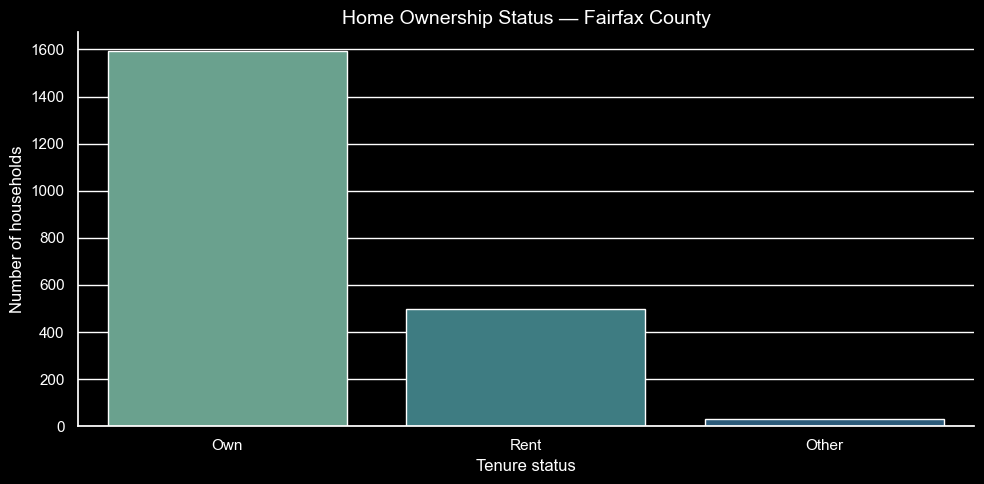

In [89]:
ownership_labels = {1: "Own", 2: "Rent", 3: "Other"}
ownership_order = ["Own", "Rent", "Other"]
ownership_data = fx_households[fx_households["HOME_OWNERSHIP"] != -9].copy()
ownership_data["Ownership"] = ownership_data["HOME_OWNERSHIP"].map(ownership_labels)
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = ownership_data, x = "Ownership", order = ownership_order, hue = "Ownership", palette = "crest", legend = False, ax = ax)
ax.set_title("Home Ownership Status — Fairfax County", fontsize = 14)
ax.set_xlabel("Tenure status")
ax.set_ylabel("Number of households")
sns.despine()
plt.tight_layout()
plt.show()

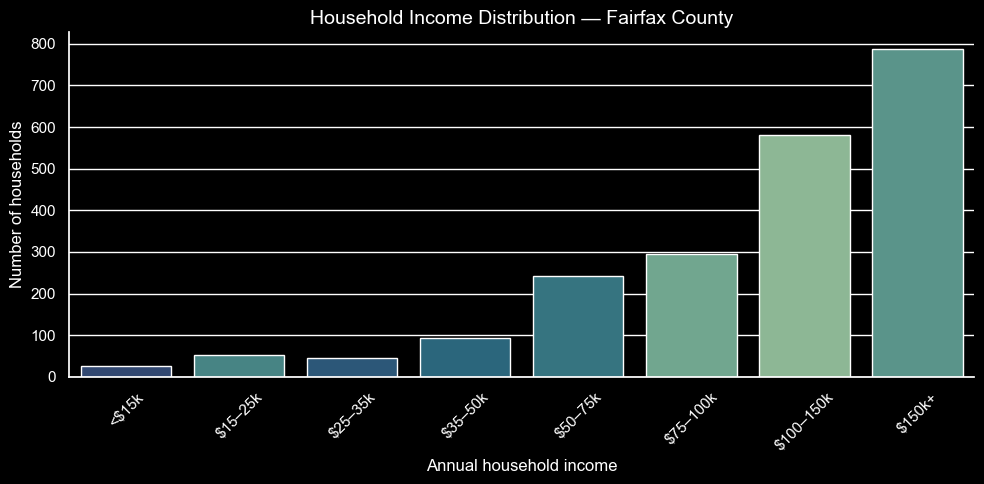

In [91]:
income_labels = {
    1: "<$15k", 2: "$15–25k", 3: "$25–35k", 4: "$35–50k",
    5: "$50–75k", 6: "$75–100k", 7: "$100–150k", 8: "$150k+",
}
income_order = [income_labels[i] for i in range(1, 9)]
income_data = fx_households.copy()
income_data["Income"] = income_data["HH_INCOME_DETAILED"].map(income_labels)
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = income_data, x = "Income", order = income_order, hue = "Income", palette = "crest", legend = False, ax = ax)
ax.set_title("Household Income Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Annual household income")
ax.set_ylabel("Number of households")
ax.tick_params(axis = "x", rotation = 45)
sns.despine()
plt.tight_layout()
plt.show()

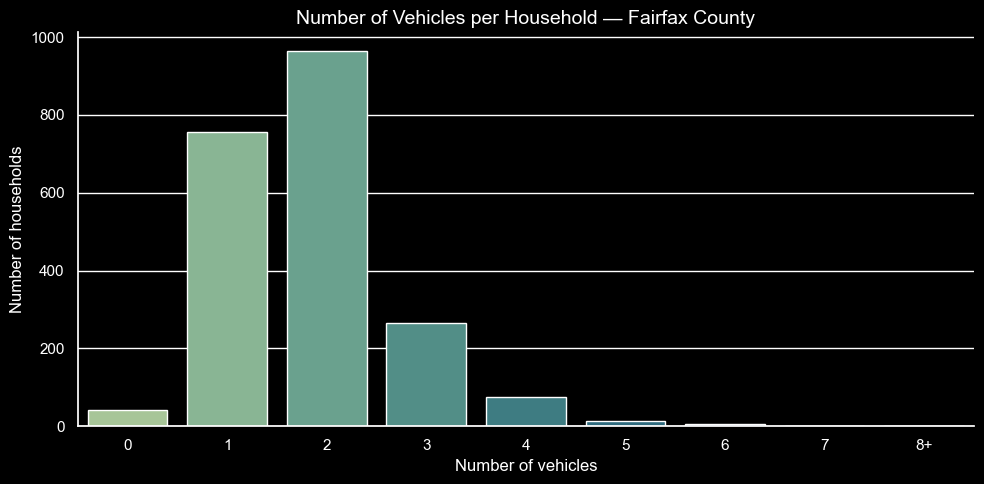

In [93]:
fig, ax = plt.subplots(figsize = (10, 5))
vehicle_order = sorted(fx_households["NUMVEHICLE"].unique())

sns.countplot(data = fx_households, x = "NUMVEHICLE", order = vehicle_order, hue = "NUMVEHICLE", palette="crest", legend = False, ax = ax)
ax.set_xticks(range(len(vehicle_order)))
ax.set_xticklabels([str(v) if v < 8 else "8+" for v in vehicle_order])
ax.set_title("Number of Vehicles per Household — Fairfax County", fontsize = 14)
ax.set_xlabel("Number of vehicles")
ax.set_ylabel("Number of households")

sns.despine()
plt.tight_layout()
plt.show()

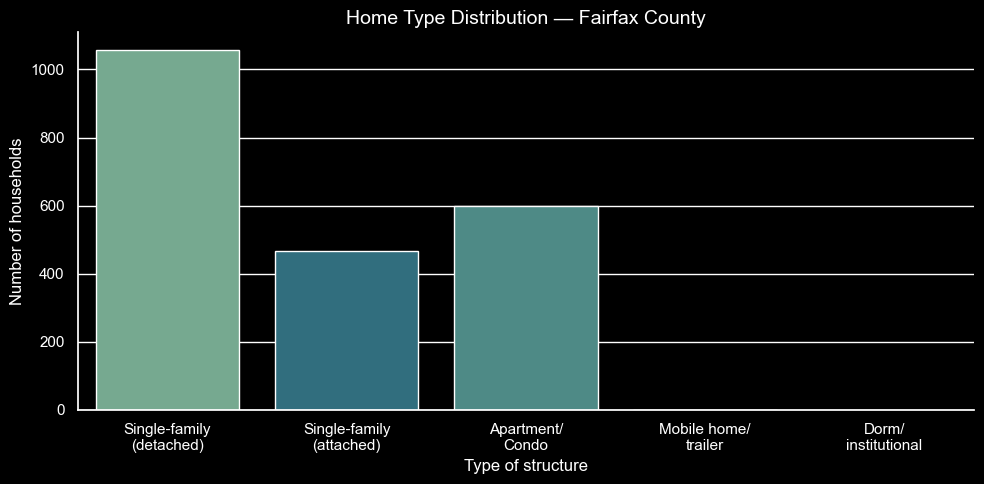

In [94]:
home_type_labels = {
    1: "Single-family\n(detached)", 2: "Single-family\n(attached)",
    3: "Apartment/\nCondo", 4: "Mobile home/\ntrailer", 5: "Dorm/\ninstitutional",
}
home_type_order = [home_type_labels[i] for i in range(1, 6)]
home_type_data = fx_households[fx_households["HOME_TYPE"] != -9].copy()
home_type_data["HomeType"] = home_type_data["HOME_TYPE"].map(home_type_labels)
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = home_type_data, x = "HomeType", order = home_type_order, hue = "HomeType", palette = "crest", legend = False, ax = ax)
ax.set_title("Home Type Distribution — Fairfax County", fontsize = 14)
ax.set_xlabel("Type of structure")
ax.set_ylabel("Number of households")
sns.despine()
plt.tight_layout()
plt.show()